In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Corrected file_path_abs to be a direct download link for an XLSX file
file_path_abs = r"https://docs.google.com/spreadsheets/d/17zYZL4wpbXoye0d9sv09F-1UFsmaQxhO/export?format=xlsx"
df = pd.read_excel(file_path_abs, engine='openpyxl') # Specify engine for .xlsx files
print(df.head())
np.random.seed(42)
df['height'] = np.random.randint(150, 181, size=len(df))

            Name            Team  Number Position  Age               Height  \
0  Avery Bradley  Boston Celtics       0       PG   25  2023-02-06 00:00:00   
1    Jae Crowder  Boston Celtics      99       SF   25  2023-06-06 00:00:00   
2   John Holland  Boston Celtics      30       SG   27  2023-05-06 00:00:00   
3    R.J. Hunter  Boston Celtics      28       SG   22  2023-05-06 00:00:00   
4  Jonas Jerebko  Boston Celtics       8       PF   29  2023-10-06 00:00:00   

   Weight            College     Salary  
0     180              Texas  7730337.0  
1     235          Marquette  6796117.0  
2     205  Boston University        NaN  
3     185      Georgia State  1148640.0  
4     231                NaN  5000000.0  


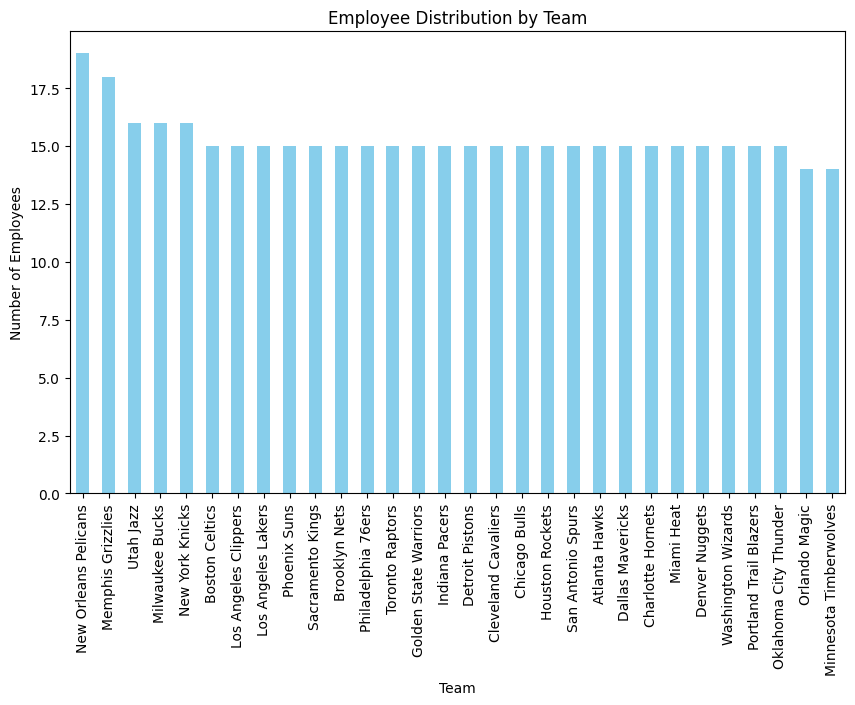

In [4]:
team_dist = df['Team'].value_counts()
team_pct = (team_dist / len(df)) * 100

plt.figure(figsize=(10, 6))
team_dist.plot(kind='bar', color='skyblue')
plt.title('Employee Distribution by Team')
plt.ylabel('Number of Employees')
plt.show()


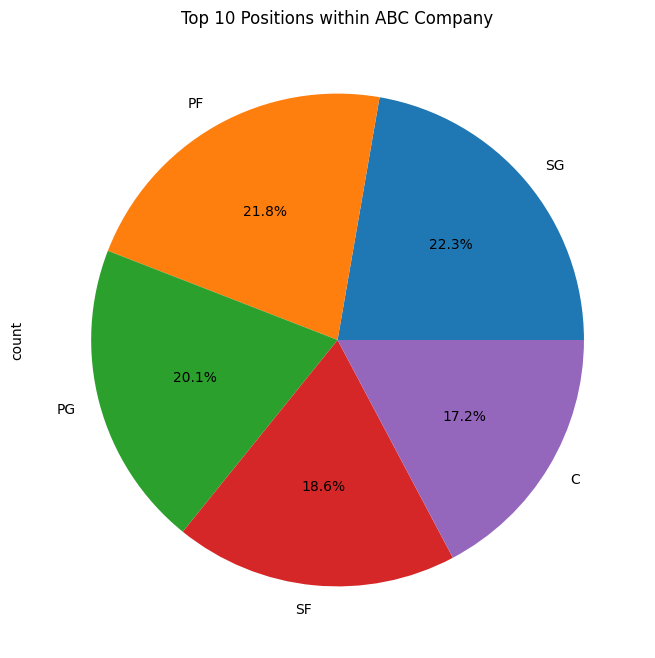

In [5]:
position_counts = df['Position'].value_counts()

plt.figure(figsize=(8, 8))
position_counts.head(10).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Positions within ABC Company')
plt.show()


/tmp/ipykernel_4926/1951080983.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age Group', data=df, palette='viridis')


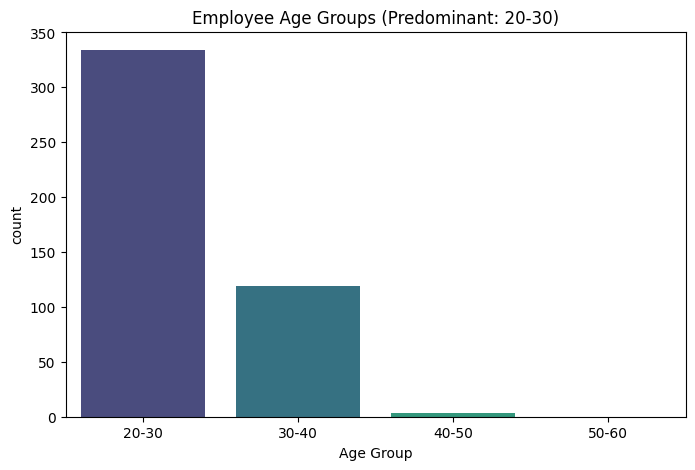

In [6]:
bins = [20, 30, 40, 50, 60]
labels = ['20-30', '30-40', '40-50', '50-60']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
age_group_predominant = df['Age Group'].value_counts().idxmax()

plt.figure(figsize=(8, 5))
sns.countplot(x='Age Group', data=df, palette='viridis')
plt.title(f'Employee Age Groups (Predominant: {age_group_predominant})')
plt.show()


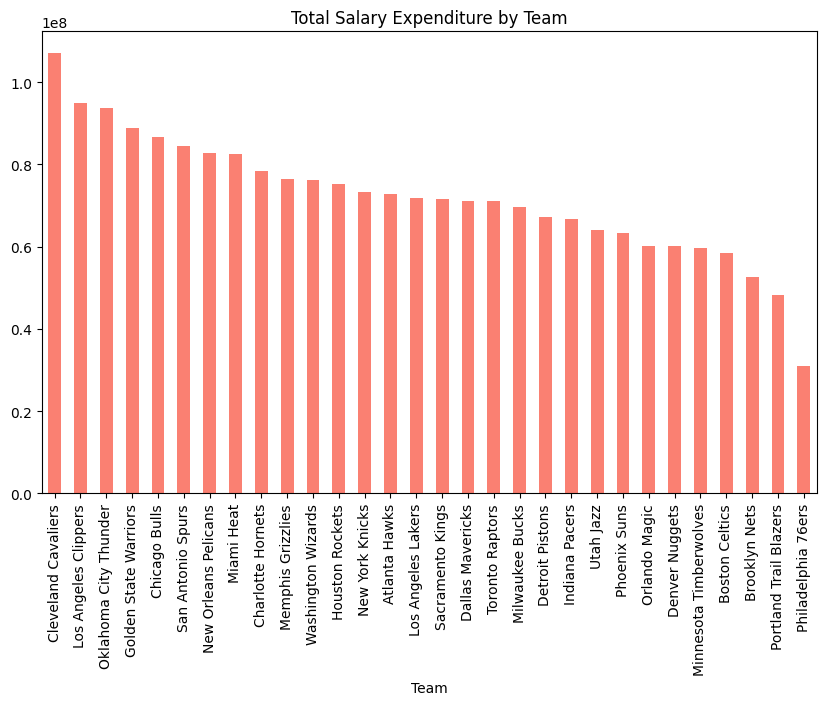

In [7]:
team_salary = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
pos_salary = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
team_salary.plot(kind='bar', color='salmon')
plt.title('Total Salary Expenditure by Team')
plt.show()


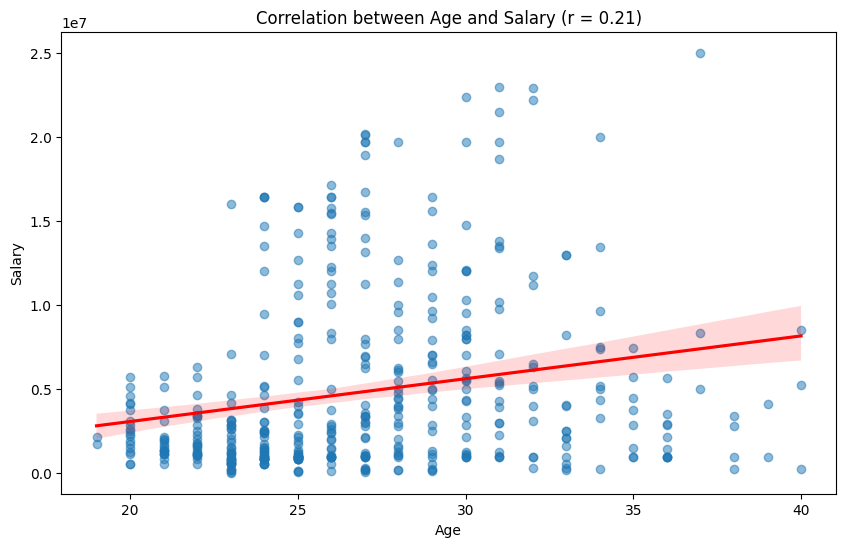

In [8]:
correlation = df['Age'].corr(df['Salary'])

plt.figure(figsize=(10, 6))
sns.regplot(x='Age', y='Salary', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Correlation between Age and Salary (r = {correlation:.2f})')
plt.show()
